# Idea grafting replicates in biomedical MeSH concepts: G4 model stage demo

This notebook is a runnable walk-through of the G4 experiment (iteration 4, experiment 9). G4 asks whether the **D2 host-entry grafting result** replicates on **191 MeSH biomedical concepts**.

**Setting.** A *host entry* is the first time a concept `c` appears in a subfield `d` outside its origin, in year `e`. The question is whether newcomers take the concept up more (`Y_strict`, W2 host papers by author-disjoint newcomers) when it arrives with partners that are already **native** to the host. That is *grafting*, measured by `A_cont`. The alternative is that it matters more that the concept arrives with its origin companions. That is *co-transfer / toolkit*, measured by `CT`.

**Estimator.** PPML (Poisson pseudo-maximum likelihood) with high-dimensional fixed effects, offset `log(n_entry_papers)`, and CRV1 standard errors clustered by concept. The Kline-Santos wild cluster score bootstrap supplies a second p value. Holm correction is applied over {A_cont, CT}.
* **R1 (primary):** concept × e + d × e fixed effects.
* **R2 (co-primary, decisive):** concept + e + d fixed effects.

**Full-run result (pre-registered, one look):** **REPLICATED**, reading GRAFTING. R2 IRR per SD of `A_cont` is **1.233 [1.117, 1.361]**, Holm p 9.7e-05, wild p 0.001 (N 2,171, 160 concepts).

**What this demo runs.** The original `method.py` is a *stage runner* over 11 stages: gates, load, coverage, events, nativeness, features, freeze, outcomes, models, report and h6. Most stages call the paid OpenAlex API and read large upstream datasets, so they cannot run here. The notebook keeps the stage runner and runs the **`models` stage** (PPML rows, wild bootstrap, Holm decision, outcome shuffle, comparison with the main pool, G4 verdict). It runs on a **100-event subset** (10 whole concepts) of the 2,249 events the artifact released in `full_method_out.json`. The functions come from the artifact's `src/` and `vendor/` modules, copied verbatim. At the end, the demo estimates are compared with the stored full-run reference.

> **Caveat:** 100 events and 10 clusters is roughly 20× less data than the decisive sample. Expect wide intervals, and some rows will not be estimable. Run on all 2,249 events, the same code reproduces R2 = 1.2330 (p 4.85e-05) exactly.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports

This is the original `method.py` import block, followed by the imports that the copied `src/models_mesh.py`, `vendor/models.py` and `vendor/ppml.py` functions need. `matplotlib` is added for the final plots. The `sys.path.insert(... "src")` and `import common` lines are dropped. Their contents (logging, `SEED` and the main-pool constants) are defined inline below.

In [2]:
from __future__ import annotations

import argparse
import json
import os
import sys
import time
from pathlib import Path

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # small dense problems; avoids BLAS oversubscription in the spawn workers

from loguru import logger  # noqa: E402

# imports used by the model-stage modules (src/models_mesh.py, vendor/models.py, vendor/ppml.py)
import types
import warnings

import numpy as np
import pandas as pd
from scipy import stats

# notebook addition: plotting for the results section
import matplotlib.pyplot as plt

# notebook addition: tiny samples can overflow exp() in IRR confidence bounds; keep the output readable
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Data loading

`mini_demo_data.json` holds:
* `datasets[0].examples`: 100 host-entry events. Each has `input` (JSON string of the W1 features), `output` (`Y_strict`) and `metadata_*` fields (`Y_lenient`, `Y_all`, `EST_bin`, retrieval flags, out-of-fold predictions).
* `metadata`: the subset rule, the frozen spec's control lists, the power/MDE results and the **full-run reference results** (`full_run_reference`).

The file is fetched from GitHub, with a local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-4/experiment-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["demo_subset"])

{'n_events': 100, 'n_concepts': 10, 'concepts': ['mesh:D000074289', 'mesh:D000076104', 'mesh:D057193', 'mesh:D000070136', 'mesh:D000068796', 'mesh:D000069376', 'mesh:D056914', 'mesh:D000076106', 'mesh:D000075282', 'mesh:D042401'], 'rule': 'whole concepts with 8-13 events, numpy seed 0 shuffle, greedy fill to <= 100 events', 'source': 'full_method_out.json (2,249 events, 187 concepts)'}


## Configuration

These are all the tunable parameters. The original (full-run) values are given in the comments.
* `N_CONCEPTS`: how many of the demo subset's 10 concepts to use. Whole concepts are kept so the concept fixed effect sees every event of a concept. The full run used all 187 concepts (2,249 events) from `full_method_out.json`.
* `WILD_REPS_MAIN` / `WILD_REPS_OTHER`: Rademacher draws of the wild cluster score bootstrap. The spec uses 999 for R1/R2 and 499 for the other rows.
* `N_SHUFFLES`: draws of the within-concept outcome-shuffle placebo. The spec uses 40.

In [5]:
N_CONCEPTS = 10          # concepts from the demo subset (max 10 here; original run: all 187 concepts / 2,249 events)
WILD_REPS_MAIN = 999     # wild bootstrap draws for R1/R2 (original: 999)
WILD_REPS_OTHER = 499    # wild bootstrap draws for the other rows (original: 499)
N_SHUFFLES = 40          # within-concept outcome shuffles (original: spec["placebo"]["outcome_shuffles"] = 40)
SEED = 20260929          # common.SEED

## Shared constants and logging (from `src/common.py`)

These are the iteration-3 reference estimates from the main (physics/CS-heavy) pool. The comparison step tests the MeSH estimate against them. `setup_logging` is simplified to a stdout sink only, because the original also writes a rotating log file.

In [6]:
# iteration-3 targets (exp_7 results/d2_models.json, d2_robustness.csv)
MAIN_COPRIMARY = {"b_A": 4.739105939721475, "se_A": 1.0102888770711833, "irr_sd": 1.300076888024346,
                  "ci": [1.1639421314281162, 1.452133975682496], "N": 1544, "G": 140}
MAIN_PRIMARY = {"b_A": 5.952633617485952, "irr_sd": 1.385942489788976, "N": 452, "G": 77}
MAIN_NONPHYS = {"b_A": 4.686456999087919, "se_A": 1.354122141289332, "irr_sd": 1.290186634471277,
                "ci": [1.112923630330427, 1.495683536950425], "N": 692, "G": 52,
                "source": "exp_7 results/d2_robustness.csv 'stratum other (descriptive)', secondary FE"}
MAIN_PHYS = {"irr_sd": 0.9516637634583498, "ci": [0.7743171600115374, 1.272165287569658], "N": 248, "G": 50,
             "source": "exp_7 results/d2_robustness.csv 'stratum Physics/Astro (descriptive)', secondary FE"}


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{module}:{line}|{message}")

## Stage runner (`method.py`)

This is the original pipeline driver. Every stage reads the outputs of earlier stages from `results/`:

| stage | what it does | runnable here? |
|---|---|---|
| gates | gate 1 + gate 2 on the main screen, harmonisation h1–h5 | no (upstream exp_7 data) |
| load | MeSH concepts, works, partner/author structures, co-word substrate | no (upstream MeSH dataset) |
| coverage | PubMed host-coverage rule + truncation audit | no (OpenAlex API) |
| events | MeSH host-entry events (W1) + G1 multi-team events | no |
| nativeness | exact OpenAlex nativeness profiles | no (OpenAlex API) |
| features | W1 features, topic hydration, leakage test | no (OpenAlex API) |
| freeze | MDE simulation + `mesh_spec.json` sha256 freeze | results in `metadata.power` |
| outcomes | author-disjoint newcomer uptake | outcomes shipped in the data |
| **models** | **PPML rows, bootstrap, Holm, placebo, verdict** | **yes (cells below)** |
| report | method_out.json, figures | OOF predictions shipped in the data |
| h6 | harmonisation h6 | no |

In the notebook, `main()` no longer parses CLI args. It logs which stages are skipped, and the `models` stage runs in the cells that follow. `common.set_ram_limit(26)` and the `logs/timings.json` write are dropped.

In [7]:
STAGES = ["gates", "load", "coverage", "events", "nativeness", "features", "freeze", "outcomes", "models", "report", "h6"]


@logger.catch(reraise=True)
def main() -> None:
    # notebook: no argparse -- the demo always runs the full stage list, executing only "models"
    setup_logging("method")
    stages = STAGES
    timings = {}
    for st in stages:
        t = time.time()
        if st == "models":
            logger.info(f"===== stage {st} ===== -> runs in the cells below on the demo subset")
        else:
            logger.info(f"===== stage {st} ===== skipped in the demo (needs the OpenAlex API / upstream datasets); "
                        f"its outputs are shipped in mini_demo_data.json")
        timings[st] = round(time.time() - t, 1)
    return timings


main()

21:01:35|INFO   |3243293448:15|===== stage gates ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


21:01:35|INFO   |3243293448:15|===== stage load ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


21:01:35|INFO   |3243293448:15|===== stage coverage ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


21:01:35|INFO   |3243293448:15|===== stage events ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


21:01:35|INFO   |3243293448:15|===== stage nativeness ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


...

21:01:35|INFO   |3243293448:15|===== stage outcomes ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


21:01:35|INFO   |3243293448:13|===== stage models ===== -> runs in the cells below on the demo subset


21:01:35|INFO   |3243293448:15|===== stage report ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


21:01:35|INFO   |3243293448:15|===== stage h6 ===== skipped in the demo (needs the OpenAlex API / upstream datasets); its outputs are shipped in mini_demo_data.json


{'gates': 0.0,
 'load': 0.0,
 'coverage': 0.0,
 'events': 0.0,
 'nativeness': 0.0,
 'features': 0.0,
 'freeze': 0.0,
 'outcomes': 0.0,
 'models': 0.0,
 'report': 0.0,
 'h6': 0.0}

## Stage `outcomes` output → model sample

The original `models` stage starts with `om = pd.read_parquet(src / "outcomes_mesh.parquet")`. Here the same table is rebuilt from the loaded events. The W1 features come from `input`, the outcome `Y_strict` from `output`, and the alternative outcomes and concept flags from the `metadata_*` fields. `N_CONCEPTS` keeps the first k concepts of the demo subset.

In [8]:
ex = data["datasets"][0]["examples"]
keep_concepts = data["metadata"]["demo_subset"]["concepts"][:N_CONCEPTS]
om = pd.DataFrame([{**json.loads(e["input"]), "Y_strict": int(e["output"]), "Y_lenient": e["metadata_Y_lenient"],
                    "Y_all": e["metadata_Y_all"], "EST_bin": e["metadata_EST_bin"],
                    "retrieval_complete": bool(e["metadata_retrieval_complete"]),
                    "rule_parity": bool(e["metadata_rule_parity"]),
                    "predict_baseline": float(e["predict_baseline"]), "predict_method": float(e["predict_method"])}
                   for e in ex if e["metadata_concept_id"] in keep_concepts])
spec = {"models": data["metadata"]["spec_models"], "prediction": data["metadata"]["prediction"],
        "placebo": {"draws": data["metadata"]["placebo_spec"]["draws"], "outcome_shuffles": N_SHUFFLES}}
print(om.shape, "events,", om.concept_id.nunique(), "concepts; mean Y_strict", round(om.Y_strict.mean(), 2))
om.head()

(100, 38) events, 10 concepts; mean Y_strict 1.11


,concept_id,o,d,e,A_cont,A_cont_lo,A_cont_hi,A_cont_exact,CT,CT_any,...,n_entry_papers,n_partners_distinct,Y_strict,Y_lenient,Y_all,EST_bin,retrieval_complete,rule_parity,predict_baseline,predict_method
0,mesh:D000068796,2805,1303,2019,0.003049,0.003049,0.003049,0.004065,0.916667,1.000000,...,1,12,1,2,2,0,True,True,0.974998,0.868245
1,mesh:D000068796,2805,1312,2013,0.225677,0.206871,0.290204,0.225677,0.500000,0.666667,...,1,12,2,3,3,0,True,True,1.318803,2.362887
2,mesh:D000068796,2805,2713,2016,0.021972,0.016479,0.266479,0.032958,0.500000,0.500000,...,1,4,0,0,0,0,True,True,1.075274,1.060681
3,mesh:D000068796,2805,2716,2019,0.136349,0.096247,0.390364,0.142976,0.294118,0.352941,...,1,17,1,1,1,0,True,True,1.532760,2.039577
4,mesh:D000068796,2805,2730,2018,0.032874,0.023908,0.296636,0.014031,1.000000,1.000000,...,1,11,0,0,0,0,True,True,0.725382,0.733007


## Vendored PPML estimator (`vendor/ppml.py`, unchanged)

This is the fast PPML with high-dimensional fixed effects:
* `_prune` iteratively drops singleton FE levels and FE levels whose outcome is all zero (separation).
* `_demean` projects out the FE space exactly, with a sparse LU solve.
* `fit` runs IRLS and returns CRV1 cluster-robust SEs with pyfixest's small-sample factor.
* `wild_score_test` is the Kline-Santos wild cluster score bootstrap (Rademacher weights, H0 imposed).

In [9]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


# notebook: stand-in for the `ppml` module so the copied code's `ppml.fit(...)` calls work unchanged
ppml = types.SimpleNamespace(fit=fit, wild_score_test=wild_score_test, _demean=_demean, _prune=_prune)

## Vendored model wrapper (`vendor/models.py`, unchanged parts)

* `FE_SPECS` maps each spec to its fixed-effect columns. `primary` is R1 (concept×e + d×e), `secondary` is R2 (concept + e + d), and there are two pre-declared alternatives.
* `fit_one` wraps `ppml.fit`. It converts each coefficient into an **IRR per SD** of the regressor on the retained sample, `exp(b·sd)`, with a t(G−1) confidence interval.
* `decide` applies the pre-declared reading. It is GRAFTING if Holm-adjusted `A_cont` is significant and positive while `CT` is not, and TOOLKIT, BOTH or NEITHER otherwise.

The module's `primary_sample`, `pyfixest_crosscheck`, `lpm_fe` and `run_models` belong to the iteration-3 screen or need pyfixest, so they are not copied.

In [10]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"

FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e


def fe_arrays(s: pd.DataFrame, spec: str) -> list[np.ndarray]:
    return [s[c].to_numpy() for c in FE_SPECS[spec]]


def fit_one(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary", wild: bool = False,
            wild_vars: tuple = (), rng=None) -> dict | None:
    X = s[xvars].to_numpy(float)
    fes = fe_arrays(s, spec)
    yv = s[y].to_numpy(float)
    r = ppml.fit(yv, X, fes, s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    if r is None:
        return None
    keep = r["keep"]
    G = r["G"]
    out = {"spec": spec, "y": y, "x": xvars, "n_input": int(len(s)), "n_retained": int(r["n"]), "G": int(G),
           "retained_share": float(r["n"] / len(s)), "coef": {}, "se": {}, "p": {}, "irr_sd": {}, "irr_01": {},
           "ci_irr_sd": {}, "sd_retained": {}}
    # singleton / separation accounting for the first FE dimension
    cells = pd.Series(fes[0]).value_counts()
    out["n_nonsingleton_fe0_cells"] = int((cells >= 2).sum())
    out["n_fe0_cells"] = int(len(cells))
    out["events_in_nonsingleton_fe0_cells"] = int(cells[cells >= 2].sum())
    tq = stats.t.ppf(0.975, G - 1)
    for i, v in enumerate(xvars):
        b, se = float(r["coef"][i]), float(r["se"][i])
        sd = float(s.loc[keep, v].std())
        tstat = b / se if se > 0 else np.nan
        out["coef"][v], out["se"][v] = b, se
        out["p"][v] = float(2 * stats.t.sf(abs(tstat), G - 1)) if se > 0 else np.nan
        out["sd_retained"][v] = sd
        out["irr_sd"][v] = float(np.exp(b * sd))
        out["irr_01"][v] = float(np.exp(b * 0.1))
        out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]
    out["deviance"] = float(2 * np.sum(np.where(r["y"] > 0, r["y"] * np.log(np.where(r["y"] > 0, r["y"], 1) / r["mu"]),
                                                 0) - (r["y"] - r["mu"])))
    if wild:
        rng = rng or np.random.default_rng(SEED)
        out["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            Xr = np.delete(X, j, axis=1)
            out["p_wild"][v] = ppml.wild_score_test(yv, Xr, X[:, j], fes, s.offset.to_numpy(), s.concept_id.to_numpy(),
                                                    rng, reps=999)
    return out


def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


def decide(res: dict) -> dict:
    bA, bC = res["coef"][A_VAR], res["coef"][CT_VAR]
    h = holm({A_VAR: res["p"][A_VAR], CT_VAR: res["p"][CT_VAR]})
    sigA, sigC = h[A_VAR] < 0.05, h[CT_VAR] < 0.05
    if sigA and bA > 0 and not (sigC and bC > 0):
        reading = "GRAFTING"
    elif sigC and bC > 0 and not sigA:
        reading = "TOOLKIT"
    elif sigA and bA > 0 and sigC and bC > 0:
        reading = "BOTH"
    else:
        reading = "NEITHER"
    notes = []
    if sigA and bA < 0:
        notes.append("significant NEGATIVE anchoring coefficient (anchoring penalty)")
    if sigC and bC < 0:
        notes.append("significant NEGATIVE co-transfer coefficient (package penalty)")
    if sigC and bC > 0 and sigA and bA < 0:
        notes.append("co-transfer premium with an anchoring penalty")
    return {"reading": reading, "holm_p": h, "notes": notes}


# notebook: stand-in for `import models as vmodels`
vmodels = types.SimpleNamespace(fit_one=fit_one, fe_arrays=fe_arrays, decide=decide, holm=holm)

## G4 model-stage helpers (`src/power_mesh.fe_cols`, `src/models_mesh.py`)

* `fe_cols` builds the integer fixed-effect codes (concept, entry year, host subfield and their interactions) and the offset `log(n_entry_papers)`.
* `sample` drops events with missing controls.
* `fit_row` fits one row and adds the wild bootstrap p values. It catches `LinAlgError`/`RuntimeError`/`ValueError`, which matters on a small subset where some FE designs are singular.
* `compact` / `decide_row` summarise a fit.
* `_shuffle` is one draw of the within-concept outcome-shuffle placebo.
* `compare` tests MeSH R2 against the main-pool estimates (z test plus IVW pooling).
* `verdict` applies the frozen G4 rule.

The only edits are the `import models as vmodels` / `import ppml` / `from power_mesh import fe_cols` lines inside the functions. They are commented out because those names are defined in the cells above.

In [11]:
_S: dict = {}


def fe_cols(s: pd.DataFrame) -> pd.DataFrame:
    s = s.copy()
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s


def sample(df: pd.DataFrame, need: list[str]) -> pd.DataFrame:
    # from power_mesh import fe_cols   (defined above)
    s = df.dropna(subset=[c for c in need if c in df.columns]).copy()
    return fe_cols(s).reset_index(drop=True)


def fit_row(s: pd.DataFrame, y: str, xvars: list[str], spec: str, wild_vars: tuple = (), reps: int = 999,
            rng=None) -> dict | None:
    # import models as vmodels / import ppml   (defined above)
    if len(s) < len(xvars) + 10:
        return None
    try:
        r = vmodels.fit_one(s, y, xvars, spec)
    except (np.linalg.LinAlgError, RuntimeError, ValueError) as ex:
        logger.warning(f"fit failed {spec} {y}: {ex!r}")
        return None
    if r is None:
        return None
    if wild_vars:
        rng = rng or np.random.default_rng(SEED)
        X = s[xvars].to_numpy(float)
        fes = vmodels.fe_arrays(s, spec)
        r["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            r["p_wild"][v] = ppml.wild_score_test(s[y].to_numpy(float), np.delete(X, j, axis=1), X[:, j], fes,
                                                  s.offset.to_numpy(), s.concept_id.to_numpy(), rng, reps=reps)
    r["n_concepts_input"] = int(s.concept_id.nunique())
    return r


def compact(r: dict | None, vars_: tuple = ("A_cont", "CT")) -> dict | None:
    if r is None:
        return None
    out = {"spec": r["spec"], "y": r["y"], "N": r["n_retained"], "N_input": r["n_input"], "G": r["G"],
           "retained_share": r["retained_share"], "controls": [x for x in r["x"] if x not in vars_]}
    for v in r["x"]:
        if v in vars_ or v in ("NATIVE", "ADJACENT", "A_placebo", "A_cont_lo", "A_cont_hi", "A_cont_exact"):
            out[v] = {"b": r["coef"][v], "se": r["se"][v], "p_crv1": r["p"][v], "irr_sd": r["irr_sd"][v],
                      "ci_irr_sd": r["ci_irr_sd"][v], "irr_01": r["irr_01"][v], "sd": r["sd_retained"][v],
                      "p_wild": (r.get("p_wild") or {}).get(v)}
    return out


def decide_row(r: dict, a: str = "A_cont") -> dict:
    # import models as vmodels   (defined above)
    rr = dict(r)
    if a != "A_cont":
        rr = {**r, "coef": {**r["coef"], "A_cont": r["coef"][a]}, "p": {**r["p"], "A_cont": r["p"][a]}}
    return vmodels.decide(rr)


def _shuffle(seed: int) -> dict:
    rng = np.random.default_rng(seed)
    s, xs, spec = _S["rows"]["R2"]
    ss = s.copy()
    y = ss.Y_strict.to_numpy().copy()
    for _, ix in ss.groupby("cfe").indices.items():
        y[ix] = y[ix][rng.permutation(len(ix))]
    ss["Y_strict"] = y
    r = fit_row(ss, "Y_strict", ["A_cont", "CT"] + xs, spec)
    return {"seed": seed, "z_A_R2": None if r is None else r["coef"]["A_cont"] / r["se"]["A_cont"]}


def compare(r2: dict) -> dict:
    b, se, sd = r2["coef"]["A_cont"], r2["se"]["A_cont"], r2["sd_retained"]["A_cont"]
    l_m, s_m = b * sd, se * sd
    out = {"mesh_R2": {"ln_irr_sd": l_m, "se": s_m, "irr_sd": float(np.exp(l_m))}}
    refs = {"main_coprimary_1.30": (MAIN_COPRIMARY["b_A"], MAIN_COPRIMARY["se_A"], MAIN_COPRIMARY["irr_sd"]),
            "main_nonphysics_1.29": (MAIN_NONPHYS["b_A"], MAIN_NONPHYS["se_A"], MAIN_NONPHYS["irr_sd"])}
    for k, (bm, sem, irr) in refs.items():
        sd_m = np.log(irr) / bm
        l_r, s_r = np.log(irr), sem * sd_m
        z = (l_m - l_r) / np.sqrt(s_m ** 2 + s_r ** 2)
        w1, w2 = 1 / s_m ** 2, 1 / s_r ** 2
        lp = (w1 * l_m + w2 * l_r) / (w1 + w2)
        sp = np.sqrt(1 / (w1 + w2))
        q = w1 * (l_m - lp) ** 2 + w2 * (l_r - lp) ** 2
        i2 = max(0.0, (q - 1) / q) if q > 0 else 0.0
        out[k] = {"ref_ln_irr_sd": float(l_r), "ref_se": float(s_r), "dlog": float(l_m - l_r), "z": float(z),
                  "p_two_sided": float(2 * stats.norm.sf(abs(z))), "ivw_pooled_irr_sd": float(np.exp(lp)),
                  "ivw_ci": [float(np.exp(lp - 1.96 * sp)), float(np.exp(lp + 1.96 * sp))],
                  "cochran_Q": float(q), "I2": float(i2)}
    return out


def verdict(a: dict, holm_p: float, p_wild: float | None, mde80: float | None, coverage: float,
            underpowered_by_design: bool) -> dict:
    """a = compact A_cont entry of the R2 row: {'irr_sd', 'ci_irr_sd', ...}."""
    irr = a["irr_sd"]
    lo, hi = a["ci_irr_sd"]
    if irr > 1 and lo > 1 and holm_p < 0.05 and (p_wild is not None and p_wild < 0.05):
        v = "REPLICATED"
    elif irr < 1 and hi < 1 and holm_p < 0.05:
        v = "REVERSED"
    elif mde80 is None or mde80 > 1.29 or underpowered_by_design:
        v = "UNDERPOWERED"
    else:
        v = "NOT_REPLICATED"
    ceiling = None
    if coverage < 0.5 and v == "REPLICATED":
        ceiling, v = "COVERAGE_LIMITED", "COVERAGE_LIMITED"
    return {"verdict": v, "irr_sd": irr, "ci95": [lo, hi], "holm_p": holm_p, "p_wild": p_wild, "MDE80_R2": mde80,
            "tag_weighted_coverage": coverage, "ceiling_applied": ceiling,
            "rule": "REPLICATED if IRR/SD > 1, 95% CI excludes 1, Holm p < .05 and p_wild < .05; REVERSED if "
                    "significantly < 1; else UNDERPOWERED if MDE80(R2) > 1.29, else NOT_REPLICATED ('claim restricted "
                    "to the physical/CS pool'); coverage < 0.5 caps REPLICATED at COVERAGE_LIMITED"}

## Stage `models` (1/5): model sample and the decisive rows R1–R4

This follows `models_mesh.run()`. The sample needs `A_cont`, `CT` and the 11 secondary controls. `add()` records each row in `R` (a compact dict) and in `rows_csv` (a flat table). R1 and R2 get wild bootstrap p values for both `A_cont` and `CT`, and R3/R4 get one for `A_cont`.

In [12]:
pc, sc = spec["models"]["primary_controls"], spec["models"]["secondary_controls"]
draws = spec["placebo"]["draws"]
shuffles = spec["placebo"]["outcome_shuffles"]
rng = np.random.default_rng(SEED)
# om = pd.read_parquet(src / "outcomes_mesh.parquet")   -> built from the loaded data above
need = ["A_cont", "CT"] + sc
s = sample(om, need)
s["_pos"] = np.arange(len(s))
base = {"n_events_outcomes": int(len(om)), "n_sample": int(len(s)), "n_concepts": int(s.concept_id.nunique()),
        "dropped_missing_controls": int(len(om) - len(s))}
logger.info(f"model sample: {base}")
R, rows_csv = {}, []


def add(key, label, r, a="A_cont"):
    R[key] = {"label": label, "row": compact(r, ("A_cont", "CT", a))}
    if r is not None:
        for v in [a, "CT"] if a != "NATIVE" else ["NATIVE", "ADJACENT", "CT"]:
            if v in r["coef"]:
                rows_csv.append({"key": key, "label": label, "spec": r["spec"], "y": r["y"], "var": v,
                                 "b": r["coef"][v], "se": r["se"][v], "p_crv1": r["p"][v],
                                 "p_wild": (r.get("p_wild") or {}).get(v), "irr_sd": r["irr_sd"][v],
                                 "irr_sd_lo": r["ci_irr_sd"][v][0], "irr_sd_hi": r["ci_irr_sd"][v][1],
                                 "irr_01": r["irr_01"][v], "sd": r["sd_retained"][v], "N": r["n_retained"],
                                 "G": r["G"], "retained_share": r["retained_share"]})
    else:
        rows_csv.append({"key": key, "label": label, "note": "not estimable (too few observations / fit failed)"})
    logger.info(f"{key}: {None if r is None else (r['n_retained'], r['G'], round(r['irr_sd'].get(a, np.nan), 3), round(r['p'].get(a, np.nan), 4))}")


r1 = fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "primary", ("A_cont", "CT"), WILD_REPS_MAIN, rng)
r2 = fit_row(s, "Y_strict", ["A_cont", "CT"] + sc, "secondary", ("A_cont", "CT"), WILD_REPS_MAIN, rng)
add("R1", "primary: concept x e + d x e", r1)
add("R2", "co-primary (G4-decisive): concept + e + d", r2)
add("R3", "concept + d x e", fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "c_plus_dxe", ("A_cont",), WILD_REPS_OTHER, rng))
add("R4", "concept x 2-year bin + d x e", fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "coarse_cx2y", ("A_cont",), WILD_REPS_OTHER, rng))
add("R2_A_only", "co-primary, A_cont without CT", fit_row(s, "Y_strict", ["A_cont"] + sc, "secondary"))

21:01:35|INFO   |1038224346:11|model sample: {'n_events_outcomes': 100, 'n_sample': 100, 'n_concepts': 10, 'dropped_missing_controls': 0}


21:01:35|INFO   |1038224346:28|R1: None


21:01:35|INFO   |1038224346:28|R2: (66, 10, 2.766, 0.1873)


21:01:35|INFO   |1038224346:28|R3: None


21:01:35|INFO   |1038224346:28|R4: None


21:01:35|INFO   |1038224346:28|R2_A_only: (66, 10, 2.455, 0.2217)


## Stage `models` (2/5): mechanism, placebo-host and sensitivity rows

These are the rows computable from the shipped event features:
* **S2 (G2):** the `A_cont` share is split into NATIVE (host share ≥ 0.30) and ADJACENT (0.05–0.30) partners, with FOREIGN as the reference.
* **S3:** placebo host. It uses the same partners' nativeness in a *random* covered host `d'`. It should be ≈ 1.
* **S4/S5:** unprofiled partner tags counted as 0 or 1.
* **S8/S9:** concept subsets (rule-parity concepts only; retrieval-complete concepts dropped).
* **S10/S11:** alternative outcomes.
* **S13:** without topic controls.
* **S16:** exact-profile nativeness only.
* **S18:** single-paper entries.

Some rows need inputs that are not in the released event table: the G1 multi-team events (S1), the coverage/kw5 flags (S6, S7, S17), the union c-paper set (S12), the host domain (S14) and pyfixest (S15). They are kept as commented-out original lines.

In [13]:
# S1 G1 multi-team entry -- needs results/outcomes_mesh_g1.parquet (not in the released event table)
# og = pd.read_parquet(src / "outcomes_mesh_g1.parquet")
# sg = sample(og, need)
# add("S1", "G1 multi-team entry (co-primary FE)", fit_row(sg, "Y_strict", ["A_cont", "CT"] + sc, "secondary", ("A_cont",), 999, rng))
# add("S1_primary", "G1 multi-team entry (primary FE)", fit_row(sg, "Y_strict", ["A_cont", "CT"] + pc, "primary"))
# S2 G2 decomposition
s2 = s.dropna(subset=["NATIVE", "ADJACENT"])
add("S2", "G2: NATIVE + ADJACENT (FOREIGN ref), co-primary",
    fit_row(s2, "Y_strict", ["NATIVE", "ADJACENT", "CT"] + sc, "secondary", ("NATIVE", "ADJACENT"), WILD_REPS_OTHER, rng), a="NATIVE")
add("S2_primary", "G2: NATIVE + ADJACENT, primary", fit_row(s2, "Y_strict", ["NATIVE", "ADJACENT", "CT"] + pc, "primary"),
    a="NATIVE")
# S3 placebo host
s3 = s.dropna(subset=["A_placebo"])
add("S3", "placebo host d' (A_placebo in place of A_cont), co-primary",
    fit_row(s3, "Y_strict", ["A_placebo", "CT"] + sc, "secondary", ("A_placebo",), WILD_REPS_OTHER, rng), a="A_placebo")
add("S4", "A_cont_lo (unprofiled = 0)", fit_row(s, "Y_strict", ["A_cont_lo", "CT"] + sc, "secondary"), a="A_cont_lo")
add("S5", "A_cont_hi (unprofiled = 1)", fit_row(s, "Y_strict", ["A_cont_hi", "CT"] + sc, "secondary"), a="A_cont_hi")
# S6 / S7 coverage-threshold subsets and S17 kw5 subset -- need covered50 / covered70 / kw5 flags (not released)
# add("S6", "coverage rule 0.50 subset (declared threshold)", fit_row(s[s.covered50], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
# add("S7", "coverage rule 0.70 subset", fit_row(s[s.covered70], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S8", "rule_parity concepts only (172)", fit_row(s[s.rule_parity], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S9", "retrieval_complete concepts dropped", fit_row(s[~s.retrieval_complete], "Y_strict", ["A_cont", "CT"] + sc,
                                                         "secondary"))
add("S10", "Y_lenient", fit_row(s, "Y_lenient", ["A_cont", "CT"] + sc, "secondary"))
add("S11", "Y_all", fit_row(s, "Y_all", ["A_cont", "CT"] + sc, "secondary"))
sc_nt = [c for c in sc if c not in ("mean_topic_score", "boundary_share")]
# S12 union c-paper set -- needs results/outcomes_mesh_union.parquet
# ou = pd.read_parquet(src / "outcomes_mesh_union.parquet")
# su = sample(ou, ["A_cont", "CT"] + sc_nt)
# add("S12", "union c-paper set (no topic controls)", fit_row(su, "Y_strict", ["A_cont", "CT"] + sc_nt, "secondary"))
s13 = sample(om, ["A_cont", "CT"] + sc_nt)
add("S13", "without topic-score controls", fit_row(s13, "Y_strict", ["A_cont", "CT"] + sc_nt, "secondary"))
# S14 host-domain strata -- need domain_d (not released)
# add("S14_health", ..., fit_row(s[s.domain_d == 4], ...)); add("S14_life", ..., fit_row(s[s.domain_d == 1], ...))
s16 = s.dropna(subset=["A_cont_exact"])
add("S16", "exact-profile nativeness only (bg fill off)",
    fit_row(s16, "Y_strict", ["A_cont_exact", "CT"] + sc, "secondary"), a="A_cont_exact")
# add("S17", "kw5 subset (declared partner rule)", fit_row(s[s.kw5], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S18", "Y_strict with n_entry_papers == 1 (single-paper entries)",
    fit_row(s[s.n_entry_papers == 1], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
# S15 EST_bin linear probability model -- uses pyfixest.feols (vmodels.lpm_fe); not run in the demo

21:01:35|INFO   |1038224346:28|S2: (66, 10, 2.7731464955706273e+119, 0.0)


21:01:35|INFO   |1038224346:28|S2_primary: None


21:01:35|INFO   |1038224346:28|S3: (66, 10, 0.722, 0.7751)


21:01:35|INFO   |1038224346:28|S4: (66, 10, 1.14, 0.8693)


21:01:35|INFO   |1038224346:28|S5: (66, 10, 1.3, 0.8693)


...

21:01:35|INFO   |1038224346:28|S11: (76, 10, 0.879, 0.8242)


21:01:35|INFO   |1038224346:28|S13: (66, 10, 1.119, 0.9189)


21:01:35|INFO   |1038224346:28|S16: (66, 10, 2.472, 0.179)


21:01:35|WARNING|2512802159:30|fit failed secondary Y_strict: RuntimeError('Factor is exactly singular')


21:01:35|INFO   |1038224346:28|S18: None


## Stage `models` (3/5): pre-declared decisions and the thin-cell rule

`decide_row` applies Holm over {A_cont, CT} within R1 and within R2 and returns the reading (GRAFTING, TOOLKIT, BOTH or NEITHER). If R1 retains fewer than 30% of events or has fewer than 50 clusters, the thin-cell rule makes R2 decisive. In the full run the rule did not trigger, and it always triggers on a 10-concept subset.

In [14]:
thin = r1 is None or r1["retained_share"] < 0.30 or r1["G"] < 50
dec = {"R1": decide_row(r1) if r1 else None, "R2": decide_row(r2) if r2 else None,
       "thin_cell_rule": {"triggered": bool(thin), "retained_share": None if r1 is None else r1["retained_share"],
                          "G": None if r1 is None else r1["G"],
                          "rule": "retained < 30% of events or G < 50 -> co-primary decisive"}}
print(json.dumps(dec, indent=1, default=float))

{
 "R1": null,
 "R2": {
  "reading": "NEITHER",
  "holm_p": {
   "A_cont": 0.3745382879097581,
   "CT": 0.7898106135941161
  },
  "notes": []
 },
 "thin_cell_rule": {
  "triggered": true,
  "retained_share": null,
  "G": null,
  "rule": "retained < 30% of events or G < 50 -> co-primary decisive"
 }
}


## Stage `models` (4/5): within-concept outcome shuffle placebo

`Y_strict` is permuted within each concept, which breaks any link between the outcome and `A_cont` while keeping each concept's outcome distribution. R2 is then refit. The two-sided p is the share of shuffled |z| at least as large as the observed |z|. The original ran this in a spawn `ProcessPoolExecutor` alongside the nativeness-permutation placebo. The permutation placebo needs the co-word graph and the raw nativeness profiles, so it is not run here. The shuffle runs serially below, and the aggregation code is copied from `placebo_run`.

In [15]:
# nat = features_mesh.load_nat(...); G = load_mesh.prepare(); arr = perm_arrays(G, nat, s)   -> not available in the demo
_S.update(rows={"R2": (s, sc, "secondary"), "R1": (s, pc, "primary")})
pl = {"draws_permutation_placebo": "not run in demo (needs the co-word graph and raw nativeness profiles)",
      "shuffles": shuffles}
if r2 is not None:
    sh = pd.DataFrame([_shuffle(SEED + 5000 + i) for i in range(shuffles)])
    zo = r2["coef"]["A_cont"] / r2["se"]["A_cont"]
    lz = sh["z_A_R2"].dropna()
    pl["outcome_shuffle_within_concept_R2"] = {"n": int(len(lz)), "z_mean": float(lz.mean()),
                                               "z_sd": float(lz.std()), "z_obs": float(zo),
                                               "p_two_sided_z": float((1 + (lz.abs() >= abs(zo)).sum()) / (1 + len(lz)))}
print(json.dumps(pl, indent=1, default=float))

21:01:35|WARNING|2512802159:30|fit failed secondary Y_strict: RuntimeError('Factor is exactly singular')


21:01:36|WARNING|2512802159:30|fit failed secondary Y_strict: RuntimeError('Factor is exactly singular')


21:01:37|WARNING|2512802159:30|fit failed secondary Y_strict: RuntimeError('Factor is exactly singular')


21:01:39|WARNING|2512802159:30|fit failed secondary Y_strict: RuntimeError('Factor is exactly singular')


{
 "draws_permutation_placebo": "not run in demo (needs the co-word graph and raw nativeness profiles)",
 "shuffles": 40,
 "outcome_shuffle_within_concept_R2": {
  "n": 36,
  "z_mean": -1.0931028908782203,
  "z_sd": 13.246439575491767,
  "z_obs": 1.4272482185467978,
  "p_two_sided_z": 0.6216216216216216
 }
}


## Stage `models` (5/5): comparison with the main pool and the G4 verdict

`compare` converts the MeSH R2 estimate and the iteration-3 main-pool estimates (1.300 co-primary, 1.29 non-physics) to log IRR per SD. It then computes a z test for the difference and an inverse-variance-weighted pooled estimate with I².

`verdict` applies the frozen rule to R2:
* **REPLICATED** if IRR/SD > 1, the CI excludes 1, Holm p < .05 and wild p < .05.
* **REVERSED** if the effect is significantly below 1.
* Otherwise **UNDERPOWERED** if the design's MDE80 exceeds 1.29, else **NOT_REPLICATED**.

MDE80 comes from the full design's power simulation, stored in the data. On the 100-event subset, the verdict describes this small sample only.

In [16]:
cmp_ = compare(r2) if r2 else None
pw = data["metadata"]["power"]                      # results/power_mesh.json
cov = float(s.n_prof_tags.sum() / s.n_tags.sum())  # tag-weighted nativeness coverage of the model sample
underpowered_by_design = data["metadata"]["underpowered_by_design"]  # results/events_mesh_summary.json
g4 = verdict(R["R2"]["row"]["A_cont"], dec["R2"]["holm_p"]["A_cont"], R["R2"]["row"]["A_cont"]["p_wild"],
             pw["MDE80_irr_per_sd"].get("R2"), cov, underpowered_by_design) if r2 else {"verdict": "NOT_ESTIMABLE"}
g4["reading_R2"] = dec["R2"]["reading"] if dec["R2"] else None
g4["reading_R1"] = dec["R1"]["reading"] if dec["R1"] else None
g4["prediction"] = spec["prediction"]
g4["prediction_consistent"] = bool(r2 and R["R2"]["row"]["A_cont"]["irr_sd"] > 1)
s2r = R.get("S2", {}).get("row")
g4["mechanism"] = {}
if s2r:
    g4["mechanism"]["G2"] = {k: {"irr_sd": s2r[k]["irr_sd"], "ci": s2r[k]["ci_irr_sd"], "p_crv1": s2r[k]["p_crv1"],
                                 "p_wild": s2r[k]["p_wild"]} for k in ("NATIVE", "ADJACENT")}
    sig = {k: s2r[k]["p_crv1"] < 0.05 and s2r[k]["irr_sd"] > 1 for k in ("NATIVE", "ADJACENT")}
    g4["mechanism"]["G2_carrier"] = ("both" if all(sig.values()) else
                                     next((k for k, v in sig.items() if v), "neither"))
out = {"sample": base, "rows": R, "decisions": dec, "placebo": pl, "comparison_main_vs_mesh": cmp_, "g4": g4}
logger.info(f"G4 VERDICT (demo subset): {g4['verdict']}  reading R2={g4['reading_R2']}  R1={g4['reading_R1']}")
print(json.dumps({k: v for k, v in g4.items() if k != "rule"}, indent=1, default=float))

21:01:39|INFO   |4212368406:20|G4 VERDICT (demo subset): NOT_REPLICATED  reading R2=NEITHER  R1=None


{
 "verdict": "NOT_REPLICATED",
 "irr_sd": 2.766255576641661,
 "ci95": [
  0.5514456086208993,
  13.876563337657663
 ],
 "holm_p": 0.3745382879097581,
 "p_wild": 0.126,
 "MDE80_R2": 1.2,
 "tag_weighted_coverage": 0.7983935742971887,
 "ceiling_applied": null,
 "reading_R2": "NEITHER",
 "reading_R1": null,
 "prediction": "IRR/SD > 1 in biomedicine, consistent with the main non-physics stratum 1.29",
 "prediction_consistent": true,
 "mechanism": {
  "G2": {
   "NATIVE": {
    "irr_sd": 2.7731464955706273e+119,
    "ci": [
     4.457229561103393e+108,
     1.7253635650732962e+130
    ],
    "p_crv1": 1.2444868100574154e-09,
    "p_wild": 0.016
   },
   "ADJACENT": {
    "irr_sd": 4.441146291699254e+154,
    "ci": [
     3.297023984195593e+140,
     5.982298120614783e+168
    ],
    "p_crv1": 1.3717962537682488e-09,
    "p_wild": 0.018
   }
  },
  "G2_carrier": "both"
 }
}


## Results: demo subset vs. full-run reference

1. **Table** of every estimated row: IRR per SD of the focal regressor with 95% CI, CRV1 p, wild p, N and G. The `full_*` columns are the full-run values for the same row.
2. **Forest plot**: demo estimates (orange) next to the full-run reference (blue) on a log scale. It also shows the main-pool references 1.300 (co-primary) and 1.29 (non-physics).
3. **Out-of-fold predictive check** on the demo events. It uses the stored grouped-by-concept 5-fold predictions of a controls-only Poisson GLM (`predict_baseline`) and of the same model plus `A_cont` and `CT` (`predict_method`), compared by mean Poisson deviance.
4. **Outcome-shuffle placebo**: the distribution of z under within-concept shuffles against the observed z.

In [17]:
ref = data["metadata"]["full_run_reference"]
tab = []
for k, v in R.items():
    r = v["row"]
    rr = ref["rows"].get(k, {})
    if r is None:
        tab.append({"row": k, "label": v["label"][:45], "var": None, "irr_sd": np.nan, "lo": np.nan, "hi": np.nan,
                    "p_crv1": np.nan, "p_wild": None, "N": None, "G": None,
                    "full_irr_sd": rr.get("irr_sd"), "full_lo": (rr.get("ci_irr_sd") or [None, None])[0],
                    "full_hi": (rr.get("ci_irr_sd") or [None, None])[1]})
        continue
    a = next(x for x in ("A_cont", "NATIVE", "A_placebo", "A_cont_lo", "A_cont_hi", "A_cont_exact") if x in r)
    tab.append({"row": k, "label": v["label"][:45], "var": a, "irr_sd": r[a]["irr_sd"], "lo": r[a]["ci_irr_sd"][0],
                "hi": r[a]["ci_irr_sd"][1], "p_crv1": r[a]["p_crv1"], "p_wild": r[a]["p_wild"], "N": r["N"], "G": r["G"],
                "full_irr_sd": rr.get("irr_sd"), "full_lo": (rr.get("ci_irr_sd") or [None, None])[0],
                "full_hi": (rr.get("ci_irr_sd") or [None, None])[1]})
tab = pd.DataFrame(tab)
pd.set_option("display.width", 220, "display.max_columns", 20, "display.float_format", "{:.3g}".format)
print(f"Demo sample: {base}")
print(tab.to_string(index=False))
print("\nG4 verdict  demo subset:", g4["verdict"], "| full run:", ref["g4_verdict"]["verdict"],
      f"(R2 IRR/SD {ref['g4_verdict']['irr_sd']:.3f} [{ref['g4_verdict']['ci95'][0]:.3f}, {ref['g4_verdict']['ci95'][1]:.3f}], "
      f"Holm p {ref['g4_verdict']['holm_p']:.2g}, wild p {ref['g4_verdict']['p_wild']})")
if cmp_:
    c = cmp_["main_coprimary_1.30"]
    rc = ref["comparison_main_vs_mesh"]["main_coprimary_1.30"]
    print(f"MeSH vs main 1.300   demo: z {c['z']:.2f}, p {c['p_two_sided']:.2f}, IVW {c['ivw_pooled_irr_sd']:.3f} | "
          f"full: z {rc['z']:.2f}, p {rc['p_two_sided']:.2f}, IVW {rc['ivw_pooled_irr_sd']:.3f}")

Demo sample: {'n_events_outcomes': 100, 'n_sample': 100, 'n_concepts': 10, 'dropped_missing_controls': 0}
       row                                         label          var    irr_sd        lo        hi   p_crv1  p_wild   N   G  full_irr_sd  full_lo  full_hi
        R1                  primary: concept x e + d x e         None       NaN       NaN       NaN      NaN     NaN NaN NaN         1.32      1.1      1.6
        R2     co-primary (G4-decisive): concept + e + d       A_cont      2.77     0.551      13.9    0.187   0.126  66  10         1.23     1.12     1.36
        R3                               concept + d x e         None       NaN       NaN       NaN      NaN     NaN NaN NaN         1.25     1.13     1.38
        R4                  concept x 2-year bin + d x e         None       NaN       NaN       NaN      NaN     NaN NaN NaN         1.38     1.22     1.57
 R2_A_only                 co-primary, A_cont without CT       A_cont      2.45     0.522      11.5    0.222     N

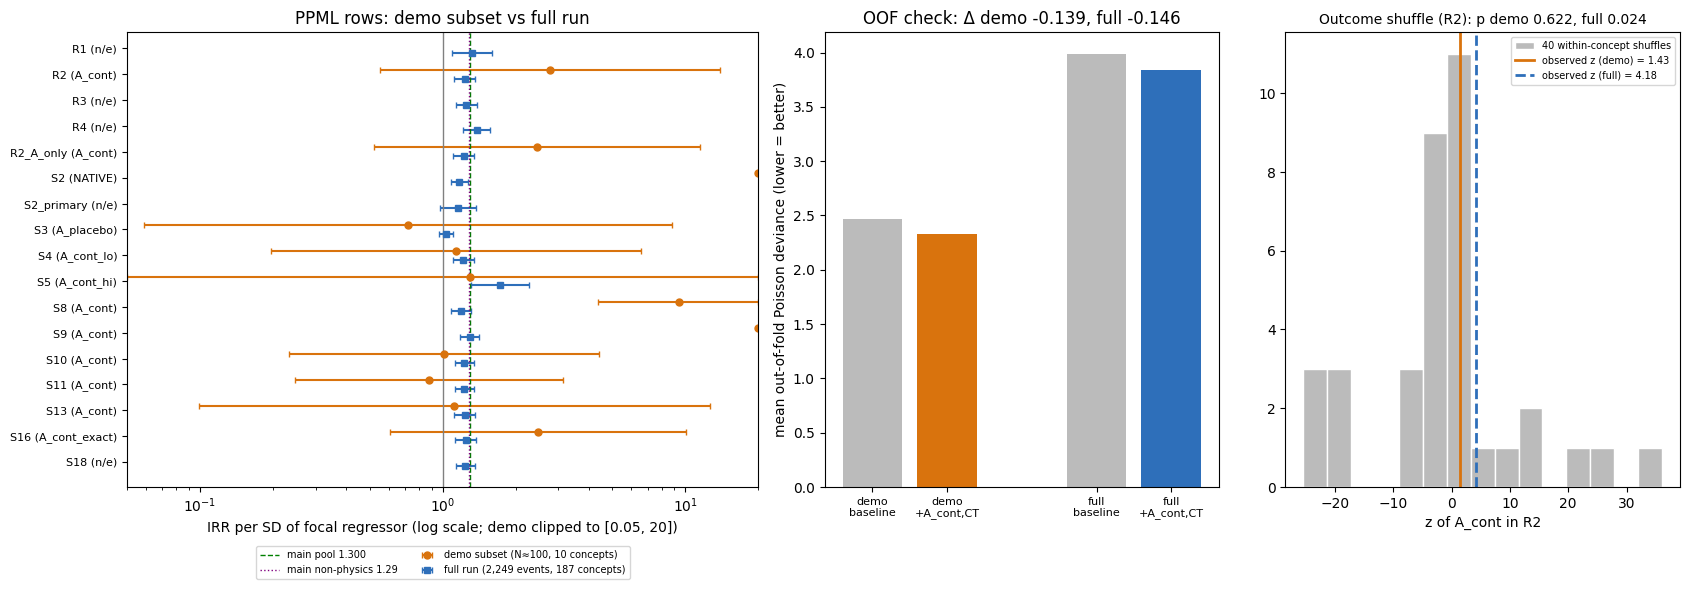

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6), gridspec_kw={"width_ratios": [1.6, 1, 1]})

# (1) forest plot: demo vs full-run reference
ax = axes[0]
t = tab.iloc[::-1].reset_index(drop=True)
yy = np.arange(len(t))
clip = lambda x: np.clip(x, 0.05, 20)
ok = t.irr_sd.notna()
ax.errorbar(clip(t.irr_sd[ok]), yy[ok] + 0.17, xerr=[clip(t.irr_sd[ok]) - clip(t.lo[ok]), clip(t.hi[ok]) - clip(t.irr_sd[ok])],
            fmt="o", color="#d9730d", ms=5, capsize=2, label=f"demo subset (N≈{base['n_sample']}, {base['n_concepts']} concepts)")
fk = t.full_irr_sd.notna()
ax.errorbar(t.full_irr_sd[fk].astype(float), yy[fk] - 0.17,
            xerr=[t.full_irr_sd[fk].astype(float) - t.full_lo[fk].astype(float), t.full_hi[fk].astype(float) - t.full_irr_sd[fk].astype(float)],
            fmt="s", color="#2e6fba", ms=5, capsize=2, label="full run (2,249 events, 187 concepts)")
ax.axvline(1, color="grey", lw=1)
ax.axvline(MAIN_COPRIMARY["irr_sd"], color="green", ls="--", lw=1, label="main pool 1.300")
ax.axvline(MAIN_NONPHYS["irr_sd"], color="purple", ls=":", lw=1, label="main non-physics 1.29")
ax.set_xscale("log"); ax.set_xlim(0.05, 20)
ax.set_yticks(yy); ax.set_yticklabels([f"{r} ({v})" for r, v in zip(t.row, t["var"].fillna("n/e"))], fontsize=8)
ax.set_xlabel("IRR per SD of focal regressor (log scale; demo clipped to [0.05, 20])")
ax.set_title("PPML rows: demo subset vs full run")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)

# (2) out-of-fold predictive check on the demo events (stored OOF predictions)
ax = axes[1]
def poisson_dev(y, mu):
    mu = np.maximum(mu, 1e-12)
    return 2 * (np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
d0 = poisson_dev(om.Y_strict.to_numpy(), om.predict_baseline.to_numpy())
d1 = poisson_dev(om.Y_strict.to_numpy(), om.predict_method.to_numpy())
oos_full = data["metadata"]["oos"]
vals = [d0.mean(), d1.mean(), oos_full["mean_deviance_baseline"], oos_full["mean_deviance_method"]]
ax.bar([0, 1, 3, 4], vals, color=["#bbbbbb", "#d9730d", "#bbbbbb", "#2e6fba"])
ax.set_xticks([0, 1, 3, 4]); ax.set_xticklabels(["demo\nbaseline", "demo\n+A_cont,CT", "full\nbaseline", "full\n+A_cont,CT"], fontsize=8)
ax.set_ylabel("mean out-of-fold Poisson deviance (lower = better)")
ax.set_title(f"OOF check: Δ demo {d1.mean() - d0.mean():+.3f}, full {oos_full['deviance_diff_method_minus_baseline']:+.3f}")

# (3) outcome-shuffle placebo
ax = axes[2]
if r2 is not None:
    ax.hist(sh["z_A_R2"].dropna(), bins=15, color="#bbbbbb", edgecolor="white", label=f"{len(sh)} within-concept shuffles")
    ax.axvline(pl["outcome_shuffle_within_concept_R2"]["z_obs"], color="#d9730d", lw=2,
               label=f"observed z (demo) = {pl['outcome_shuffle_within_concept_R2']['z_obs']:.2f}")
    ax.axvline(ref["placebo"]["R2"]["z_obs"], color="#2e6fba", lw=2, ls="--",
               label=f"observed z (full) = {ref['placebo']['R2']['z_obs']:.2f}")
    ax.set_title(f"Outcome shuffle (R2): p demo {pl['outcome_shuffle_within_concept_R2']['p_two_sided_z']:.3f}, "
                 f"full {ref['placebo']['outcome_shuffle_within_concept_R2']['p_two_sided_z']:.3f}", fontsize=10)
    ax.set_xlabel("z of A_cont in R2"); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Reading the output

* On the 100-event, 10-concept subset, R1 (concept × year FE) is usually not estimable, and the other rows have wide intervals. The per-row estimates therefore scatter around the full-run values instead of reproducing them. This is the same pattern the full run's power analysis predicts: MDE80 is 1.20 for R2 even with 2,171 events.
* The **full-run reference** (blue) is the artifact's pre-registered result: **REPLICATED**, reading GRAFTING in both R1 and R2. The MeSH R2 of 1.233 does not differ from the main pool's 1.300 (z −0.71, p 0.48; IVW pooled 1.262). The placebo host is null (1.031), and the effect is carried by both NATIVE and ADJACENT partners.
* **To reproduce the full numbers:** build `om` from all 2,249 examples of the artifact's `full_method_out.json` (same format as `mini_demo_data.json`) and rerun the model-stage cells. R2 then comes out at IRR/SD 1.2330, p 4.85e-05, N 2,171, G 160. On all 2,249 events, an R2 fit plus a 999-draw wild test takes well under a second, so the whole model stage stays fast.